# Pediatric Brain Tumor Measurement (pedBRATS 2024)

Revised pipeline for quantifying whole tumors from segmentation masks in the `data/` folder.

**Label map (as displayed in ITK-SNAP)**

| Label | Region |
|-------|--------|
| 1 | Enhancing tumor |
| 2 | Non-enhancing tumor |
| 3 | Cyst |
| 4 | Edema |

**Whole-tumor construction**: labels 1 ∪ 2 ∪ 3, plus label 4 (edema) **only where edema is spatially connected to labels 1–3**. Disconnected edema is excluded.

**Measurements**
- `axial_slice_index` / `area_mm2` — axial slice with the largest tumor pixel count and its in-plane tumor area.
- `ap_mm` / `tra_mm` — on that axial slice, the **longest in-plane tumor diameter** (AP) and the **perpendicular short-axis diameter** (Tra), both computed from the tumor contour (no bounding-box width/height). Lengths are reported **edge-to-edge** (extending half a pixel beyond each endpoint), matching ruler tools in ITK-SNAP / 3D Slicer.
- `sagittal_slice_index` / `cc_mm` — the craniocaudal extent is calculated **separately** as the **maximum superior–inferior (z) span of the tumor on the sagittal view**: for every (x, y) column we take `(z_top − z_bottom + 1) × z_spacing` and report the largest value. `sagittal_slice_index` is the sagittal slice (`x`) on which that maximum sits.
- `volume_mm3` / `volume_cm3` — total physical volume of the whole-tumor mask, `Σ(voxel_count) × x_spacing × y_spacing × z_spacing`.

Slice indices in the CSV are **1-based** (matching ITK-SNAP / 3D Slicer). The in-memory numpy arrays inside the code are 0-based as usual.

Supports `.nii`, `.nii.gz`, and `.mha` segmentation files via SimpleITK; voxel spacing is read from the NIfTI / MHA header and used for every physical-unit conversion.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import cv2
import numpy as np
import pandas as pd
import SimpleITK as sitk
from scipy.ndimage import binary_dilation, label as cc_label
from scipy.spatial.distance import cdist

# ── Configuration ─────────────────────────────────────────────────────────────────────────
DATA_DIR = Path("data")
OUTPUT_CSV = Path("tumor_measurements_by_case.csv")

# Label semantics (pedBRATS 2024)
LABEL_ENHANCING = 1
LABEL_NON_ENHANCING = 2
LABEL_CYST = 3
LABEL_EDEMA = 4
CORE_LABELS = (LABEL_ENHANCING, LABEL_NON_ENHANCING, LABEL_CYST)

# File-matching rules
# Matches modality volumes whose name contains `_0000` .. `_0004` before the extension,
# possibly followed by extra tags like `_ss` or ` copy`.
MODALITY_SUFFIX_RE = re.compile(r"_000[0-4]([_\s][^/]*)?\.nii(\.gz)?$", re.IGNORECASE)
SEG_EXTENSIONS = (".nii", ".nii.gz", ".mha")
# When a case folder contains multiple segmentation candidates, these tokens indicate the preferred (reviewed / latest) version.
PREFERRED_TOKENS = ("REVISED", "UPDATED", "v2", "V2", "my_", "MY_", "ens", "ENS", "E-", "E_")
# Segmentation masks are integer-valued label volumes; reject any candidate whose
# unique value count exceeds this (i.e. it's probably a modality image).
MAX_SEG_UNIQUE_VALUES = 16

np.set_printoptions(suppress=True, precision=3)

## 1. Case discovery and loading

For each case folder we exclude modality volumes (`*_0000` … `*_0003`) and macOS metadata sidecars (`._*`). When more than one segmentation candidate remains we prefer the variant tagged as `REVISED` / `UPDATED` / `v2` / `my_` / `E-` — these are the reviewed or latest segmentations in this dataset.

In [2]:
def _is_seg_candidate(p: Path) -> bool:
    if not p.is_file() or p.name.startswith("."):
        return False
    lower = p.name.lower()
    if not lower.endswith(SEG_EXTENSIONS):
        return False
    if MODALITY_SUFFIX_RE.search(p.name):
        return False
    return True


def _looks_like_label_volume(path: Path) -> bool:
    """Return True if the file loads as an integer label map with few unique values.

    This is our fallback filter when naming alone cannot distinguish a segmentation
    from a raw modality volume that happens to share a similar filename pattern.
    """
    try:
        arr = sitk.GetArrayViewFromImage(sitk.ReadImage(str(path)))
    except Exception:
        return False
    # Subsample for speed on large volumes.
    flat = np.asarray(arr).ravel()
    if flat.size > 5_000_000:
        flat = flat[:: max(1, flat.size // 5_000_000)]
    uniq = np.unique(flat)
    if uniq.size > MAX_SEG_UNIQUE_VALUES:
        return False
    if not np.all(uniq == uniq.astype(np.int64)):
        return False
    if uniq.min() < 0 or uniq.max() > 20:
        return False
    return True


def find_segmentation_file(case_dir: Path) -> Path | None:
    """Pick the most likely segmentation file in a case directory."""
    candidates = [f for f in case_dir.iterdir() if _is_seg_candidate(f)]
    if not candidates:
        return None

    def score(f: Path) -> tuple:
        token_score = sum(1 for tok in PREFERRED_TOKENS if tok in f.name)
        # Prefer name tokens first; otherwise the smaller file is far more likely to
        # be a compressed label map than a raw modality volume.
        return (token_score, -f.stat().st_size, f.name)

    candidates.sort(key=score, reverse=True)

    # If the top-scoring candidate doesn't look like a label map, drop down the list.
    for cand in candidates:
        if _looks_like_label_volume(cand):
            return cand
    # Fall back to the top candidate even if validation failed, so the caller can surface the issue.
    return candidates[0]


def case_id_from_dir(case_dir: Path) -> str:
    """Use the folder name verbatim as the case id."""
    return case_dir.name


def load_segmentation(path: Path) -> tuple[np.ndarray, tuple[float, float, float], sitk.Image]:
    """Load a segmentation volume.

    Returns
    -------
    array : np.ndarray, int16, shape (Z, Y, X)
    spacing_xyz : (x_spacing, y_spacing, z_spacing) in mm
    image : original SimpleITK image (for metadata / orientation).
    """
    image = sitk.ReadImage(str(path))
    array = sitk.GetArrayFromImage(image).astype(np.int16)
    spacing_xyz = tuple(float(s) for s in image.GetSpacing())
    return array, spacing_xyz, image


print(f"Found {sum(1 for d in DATA_DIR.iterdir() if d.is_dir() and not d.name.startswith('.'))} case directories under {DATA_DIR}")

Found 267 case directories under data


## 2. Whole-tumor mask with connected-edema inclusion

The whole-tumor mask starts from labels 1–3 (enhancing, non-enhancing, cyst). Each 26-connected edema component (label 4) is kept **only if it touches the core** (i.e. it shares a face/edge/corner with a voxel in labels 1–3). Detached edema is discarded.

In [3]:
def build_whole_tumor_mask(seg: np.ndarray) -> np.ndarray:
    """Whole tumor = labels 1∲3 ∪ edema components connected to labels 1∲3."""
    core = np.isin(seg, CORE_LABELS)
    edema = seg == LABEL_EDEMA

    if not edema.any():
        return core

    # 26-connectivity for 3D adjacency (face/edge/corner neighbors).
    structure = np.ones((3, 3, 3), dtype=bool)
    core_dilated = binary_dilation(core, structure=structure)

    labeled, n_components = cc_label(edema, structure=structure)
    if n_components == 0:
        return core

    # Keep components that overlap the dilated core (i.e. are adjacent to labels 1∲3).
    keep_ids = set(np.unique(labeled[core_dilated & edema]).tolist())
    keep_ids.discard(0)
    if not keep_ids:
        return core
    connected_edema = np.isin(labeled, list(keep_ids))
    return core | connected_edema

## 3. Contour-based 2D measurement (long axis + perpendicular short axis)

On the axial slice with the **largest tumor pixel count** we compute:

1. All external tumor contour points (in physical mm), pooled across every tumor component on that slice.
2. The **long axis** = pair of contour points with maximum pairwise Euclidean distance.
3. The **perpendicular short axis** = the longest chord through the (filled) tumor that is perpendicular to the long axis. We rotate the filled tumor pixel coordinates into the long-axis frame and, for each fine bin along the long axis, take the perpendicular spread; the maximum spread is the short-axis length.

No bounding-box (min/max index) is used for in-plane dimensions.

In [4]:
@dataclass
class AxialMeasurement:
    slice_index: int
    area_mm2: float
    long_mm: float
    short_mm: float
    long_endpoints: tuple[np.ndarray, np.ndarray] | None  # in pixel coords (x_pix, y_pix)
    short_endpoints: tuple[np.ndarray, np.ndarray] | None  # in pixel coords (x_pix, y_pix)


def _segment_inside_mask(
    mask2d: np.ndarray,
    p0_pix: np.ndarray,
    p1_pix: np.ndarray,
    tolerance: float = 0.0,
) -> bool:
    """True iff the line segment from p0_pix to p1_pix lies entirely within mask2d.

    Both endpoints are in pixel coordinates (x_pix, y_pix). We sample the line at
    3x the natural pixel resolution (nearest-neighbor) and require ``1 - tolerance``
    of the samples to be inside the tumor; ``tolerance=0`` enforces a strict
    in-tumor constraint.
    """
    dx = p1_pix[0] - p0_pix[0]
    dy = p1_pix[1] - p0_pix[1]
    n = int(np.ceil(max(abs(dx), abs(dy)))) * 3 + 1
    if n < 2:
        n = 2
    ts = np.linspace(0.0, 1.0, n)
    xs = np.round(p0_pix[0] + ts * dx).astype(int)
    ys = np.round(p0_pix[1] + ts * dy).astype(int)
    h, w = mask2d.shape
    xs = np.clip(xs, 0, w - 1)
    ys = np.clip(ys, 0, h - 1)
    inside = mask2d[ys, xs] > 0
    if tolerance <= 0.0:
        return bool(inside.all())
    return bool(inside.mean() >= 1.0 - tolerance)


def _slice_contour_points_mm(
    mask2d: np.ndarray, x_spacing: float, y_spacing: float
) -> tuple[np.ndarray, np.ndarray]:
    """Return (pts_mm, pts_pix) where points come from all external contours pooled.

    pts_mm / pts_pix have shape (N, 2), ordered as (x, y).
    """
    mask_u8 = (mask2d > 0).astype(np.uint8)
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.empty((0, 2)), np.empty((0, 2))
    pts_pix = np.vstack([c.reshape(-1, 2) for c in contours]).astype(np.float64)
    pts_mm = np.column_stack([pts_pix[:, 0] * x_spacing, pts_pix[:, 1] * y_spacing])
    return pts_mm, pts_pix


def _pixel_extent_along(direction: np.ndarray, x_spacing: float, y_spacing: float) -> float:
    """Physical extent of a single pixel projected onto `direction` (unit vector).

    For axis-aligned direction this equals the spacing along that axis. For a 45°
    direction with isotropic spacing it equals spacing*sqrt(2). This is exactly the
    correction that converts a center-to-center distance into an edge-to-edge
    distance in that direction.
    """
    return float(abs(direction[0]) * x_spacing + abs(direction[1]) * y_spacing)


def _long_axis_from_contour(
    mask2d: np.ndarray,
    pts_mm: np.ndarray,
    pts_pix: np.ndarray,
    x_spacing: float,
    y_spacing: float,
) -> tuple[float, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Longest diameter across pooled contour points that stays inside the tumor.

    Candidate endpoints are the pooled contour points (subsampled if there are
    many). Pairs are tested in descending distance order; the first pair whose
    connecting segment lies *entirely* within the tumor mask is returned. This
    rejects hull chords that would cross concave gaps in the tumor.

    Returns (length_mm, p1_mm_center, p2_mm_center, p1_pix_edge, p2_pix_edge).
    The reported length is edge-to-edge (center distance + one projected pixel
    width); pixel endpoints are extended half a pixel outward for drawing.
    """
    if len(pts_mm) < 2:
        zero = np.zeros(2)
        return 0.0, zero, zero, zero, zero

    # Subsample very long contours to keep the pairwise search tractable.
    max_pts = 600
    if len(pts_mm) > max_pts:
        idx = np.linspace(0, len(pts_mm) - 1, max_pts).astype(int)
        pts_mm = pts_mm[idx]
        pts_pix = pts_pix[idx]

    d_full = cdist(pts_mm, pts_mm)
    n = len(pts_mm)
    iu, ju = np.triu_indices(n, k=1)
    dists = d_full[iu, ju]
    order = np.argsort(-dists)

    # Cap the number of candidates we segment-check; real tumor diameters are
    # always among the longest few dozen pairs.
    max_checks = min(len(order), 5000)

    best_i = int(iu[order[0]])
    best_j = int(ju[order[0]])
    best_len = float(dists[order[0]])

    for k in order[:max_checks]:
        i = int(iu[k])
        j = int(ju[k])
        if _segment_inside_mask(mask2d, pts_pix[i], pts_pix[j]):
            best_i, best_j, best_len = i, j, float(dists[k])
            break

    p1_mm_center = pts_mm[best_i]
    p2_mm_center = pts_mm[best_j]
    center_len = best_len
    if center_len == 0.0:
        return 0.0, p1_mm_center, p2_mm_center, pts_pix[best_i], pts_pix[best_j]

    axis = p2_mm_center - p1_mm_center
    u = axis / center_len
    extend = 0.5 * _pixel_extent_along(u, x_spacing, y_spacing)

    p1_mm_edge = p1_mm_center - extend * u
    p2_mm_edge = p2_mm_center + extend * u
    length_mm = center_len + 2 * extend  # edge-to-edge

    p1_pix_edge = np.array([p1_mm_edge[0] / x_spacing, p1_mm_edge[1] / y_spacing])
    p2_pix_edge = np.array([p2_mm_edge[0] / x_spacing, p2_mm_edge[1] / y_spacing])
    return length_mm, p1_mm_center, p2_mm_center, p1_pix_edge, p2_pix_edge


def _short_axis_perpendicular(
    mask2d: np.ndarray,
    p1_mm: np.ndarray,
    p2_mm: np.ndarray,
    x_spacing: float,
    y_spacing: float,
) -> tuple[float, np.ndarray | None, np.ndarray | None]:
    """Longest chord through the tumor that is perpendicular to the long axis.

    The chord must stay *inside* the tumor — for non-convex or multi-component
    tumors the method never bridges empty regions between two lobes. At each
    along-position (sampled at half-pixel resolution) we collect the tumor
    pixels that intersect that cross-section, sort them in the perpendicular
    direction, and split them into contiguous runs (two consecutive pixels are
    considered connected only if their perpendicular gap is within ~one pixel).
    The longest contiguous run across all along-positions is the short axis.
    Lengths are reported edge-to-edge (half a pixel added at each end).

    Returns (length_mm, q1_pix_edge, q2_pix_edge).
    """
    axis = p2_mm - p1_mm
    axis_len = float(np.linalg.norm(axis))
    if axis_len == 0.0:
        return 0.0, None, None
    u = axis / axis_len                 # along the long axis
    v = np.array([-u[1], u[0]])         # perpendicular (rotated 90°)

    ys_pix, xs_pix = np.where(mask2d > 0)
    if xs_pix.size == 0:
        return 0.0, None, None
    pts_mm = np.column_stack([xs_pix * x_spacing, ys_pix * y_spacing])
    rel = pts_mm - p1_mm
    along = rel @ u
    perp = rel @ v

    along_pixel_w = _pixel_extent_along(u, x_spacing, y_spacing)
    perp_pixel_w = _pixel_extent_along(v, x_spacing, y_spacing)
    bin_w = max(along_pixel_w, 1e-3)
    # Two consecutive tumor pixels within a cross-section are considered connected
    # when their perpendicular centers are within ~1.5× the perpendicular pixel
    # width. Larger gaps indicate non-tumor (empty space) between two tumor lobes.
    gap_tol = perp_pixel_w * 1.5

    order = np.argsort(along)
    along_s = along[order]
    perp_s = perp[order]

    best_len = 0.0
    best_q1_pix = None
    best_q2_pix = None

    # Sample along-positions at half-pixel resolution so we don't miss the widest
    # cross-section between bin boundaries.
    step = bin_w / 2
    a_lo_val, a_hi_val = along_s[0], along_s[-1]
    n_steps = max(1, int(np.ceil((a_hi_val - a_lo_val) / step)) + 1)
    a_samples = a_lo_val + np.arange(n_steps) * step

    for a in a_samples:
        lo = np.searchsorted(along_s, a - bin_w / 2, side="left")
        hi = np.searchsorted(along_s, a + bin_w / 2, side="right")
        if hi <= lo:
            continue
        window_perp = np.sort(perp_s[lo:hi])
        if window_perp.size == 1:
            run_len = perp_pixel_w
            if run_len > best_len:
                best_len = run_len
                q1_mm = p1_mm + a * u + (window_perp[0] - 0.5 * perp_pixel_w) * v
                q2_mm = p1_mm + a * u + (window_perp[0] + 0.5 * perp_pixel_w) * v
                best_q1_pix = np.array([q1_mm[0] / x_spacing, q1_mm[1] / y_spacing])
                best_q2_pix = np.array([q2_mm[0] / x_spacing, q2_mm[1] / y_spacing])
            continue

        # Split the sorted perp values into contiguous runs by detecting gaps.
        gaps = np.diff(window_perp)
        break_positions = np.where(gaps > gap_tol)[0]
        starts = np.concatenate(([0], break_positions + 1))
        ends = np.concatenate((break_positions + 1, [window_perp.size]))

        for s, e in zip(starts, ends):
            run = window_perp[s:e]
            run_len = float(run[-1] - run[0]) + perp_pixel_w
            if run_len > best_len:
                best_len = run_len
                q1_mm = p1_mm + a * u + (run[0] - 0.5 * perp_pixel_w) * v
                q2_mm = p1_mm + a * u + (run[-1] + 0.5 * perp_pixel_w) * v
                best_q1_pix = np.array([q1_mm[0] / x_spacing, q1_mm[1] / y_spacing])
                best_q2_pix = np.array([q2_mm[0] / x_spacing, q2_mm[1] / y_spacing])

    if best_q1_pix is None:
        return 0.0, None, None
    return best_len, best_q1_pix, best_q2_pix


def measure_axial(
    whole_tumor_mask: np.ndarray, x_spacing: float, y_spacing: float
) -> AxialMeasurement | None:
    if not whole_tumor_mask.any():
        return None
    slice_pixel_counts = np.array(
        [np.count_nonzero(whole_tumor_mask[z]) for z in range(whole_tumor_mask.shape[0])]
    )
    if slice_pixel_counts.max() == 0:
        return None
    best_z = int(np.argmax(slice_pixel_counts))
    mask2d = whole_tumor_mask[best_z]
    area_mm2 = float(np.count_nonzero(mask2d) * x_spacing * y_spacing)

    pts_mm, pts_pix = _slice_contour_points_mm(mask2d, x_spacing, y_spacing)
    if len(pts_mm) < 2:
        return AxialMeasurement(best_z, area_mm2, 0.0, 0.0, None, None)

    long_mm, p1_mm_center, p2_mm_center, p1_pix_edge, p2_pix_edge = _long_axis_from_contour(
        mask2d, pts_mm, pts_pix, x_spacing, y_spacing
    )
    short_mm, q1_pix, q2_pix = _short_axis_perpendicular(
        mask2d, p1_mm_center, p2_mm_center, x_spacing, y_spacing
    )

    long_ends = (p1_pix_edge, p2_pix_edge)
    short_ends = (q1_pix, q2_pix) if q1_pix is not None and q2_pix is not None else None
    return AxialMeasurement(best_z, area_mm2, long_mm, short_mm, long_ends, short_ends)

## 4. Craniocaudal extent (sagittal view) and volume

The craniocaudal extent is calculated **separately** from AP / Tra as the **maximum superior–inferior span of the tumor on the sagittal view**.

For every sagittal slice (fixed `x`), and within each slice for every column (fixed `y`), we measure the run of tumor voxels along z from the most superior to the most inferior voxel and take the largest such run across all `(x, y)`:

```python
# whole_tumor_mask shape (Z, Y, X)
zs_per_xy = np.where(whole_tumor_mask, np.arange(Z)[:, None, None], -1)  # conceptually
# cc_mm = max over (x, y) of (z_top - z_bottom + 1) * z_spacing
```

The reported `cc_mm` is therefore a true cranio-caudal extent in millimetres. `sagittal_slice_index` is the sagittal slice (`x`) on which that maximum occurred, recorded so the measurement can be reproduced in ITK-SNAP / 3D Slicer.

The whole-tumor volume is `Σ(voxel_count) × x_spacing × y_spacing × z_spacing`, using the spacing read from the NIfTI / MHA header.

In [5]:
@dataclass
class SagittalMeasurement:
    slice_index: int            # sagittal slice (x) where the max CC span occurs
    cc_mm: float                # max superior–inferior tumor span (mm)
    y_at_max: int               # y-column on that slice where the max span sits
    z_lo: int                   # most-inferior tumor z on that (x, y) column
    z_hi: int                   # most-superior tumor z on that (x, y) column


def measure_sagittal_cc(
    whole_tumor_mask: np.ndarray, z_spacing: float
) -> SagittalMeasurement | None:
    """Maximum superior–inferior (z) span of the tumor on the sagittal view.

    For every (x, y) column we take ``(z_top − z_bottom + 1) × z_spacing`` and
    return the global maximum. `slice_index` (`x`) and `y_at_max` together
    identify the actual column where that ruler sits, so it can be reproduced
    in ITK-SNAP and the visualizer can anchor the line to real tumor voxels
    (instead of a synthetic mid-slice coordinate, which is why the old overlay
    drifted outside the mask on tilted / curved tumors).

    `whole_tumor_mask` has shape (Z, Y, X).
    """
    if not whole_tumor_mask.any():
        return None

    Z, Y, X = whole_tumor_mask.shape
    z_idx = np.arange(Z, dtype=np.int32)[:, None, None]              # (Z, 1, 1)

    # Per (y, x): top/bottom z of any tumor voxel; -1 sentinels indicate empty columns.
    z_hi = np.where(whole_tumor_mask, z_idx, -1).max(axis=0)         # (Y, X)
    z_lo = np.where(whole_tumor_mask, z_idx, Z).min(axis=0)          # (Y, X)
    has_tumor = z_hi >= 0
    if not has_tumor.any():
        return None

    span_vox = np.where(has_tumor, z_hi - z_lo + 1, 0)                # (Y, X)
    flat_idx = int(np.argmax(span_vox))
    y_max, x_max = np.unravel_index(flat_idx, span_vox.shape)
    cc_mm = float(span_vox[y_max, x_max] * z_spacing)

    return SagittalMeasurement(
        slice_index=int(x_max),
        cc_mm=cc_mm,
        y_at_max=int(y_max),
        z_lo=int(z_lo[y_max, x_max]),
        z_hi=int(z_hi[y_max, x_max]),
    )


def compute_volume_mm3(
    whole_tumor_mask: np.ndarray, spacing_xyz: tuple[float, float, float]
) -> float:
    vx = float(spacing_xyz[0] * spacing_xyz[1] * spacing_xyz[2])
    return float(np.count_nonzero(whole_tumor_mask) * vx)

## 5. Per-case measurement

In [6]:
@dataclass
class CaseMeasurement:
    case_id: str
    axial_slice_index: int
    area_mm2: float
    ap_mm: float
    tra_mm: float
    sagittal_slice_index: int
    cc_mm: float
    volume_mm3: float
    volume_cm3: float
    axial: AxialMeasurement | None = None
    sagittal: SagittalMeasurement | None = None
    whole_tumor_mask: np.ndarray | None = None


def measure_case(case_dir: Path, keep_mask: bool = False) -> CaseMeasurement | None:
    seg_path = find_segmentation_file(case_dir)
    if seg_path is None:
        return None
    seg, spacing_xyz, _img = load_segmentation(seg_path)
    x_sp, y_sp, z_sp = spacing_xyz

    mask = build_whole_tumor_mask(seg)
    if not mask.any():
        return CaseMeasurement(
            case_id=case_id_from_dir(case_dir),
            axial_slice_index=-1,
            area_mm2=0.0,
            ap_mm=0.0,
            tra_mm=0.0,
            sagittal_slice_index=-1,
            cc_mm=0.0,
            volume_mm3=0.0,
            volume_cm3=0.0,
        )

    axial = measure_axial(mask, x_sp, y_sp)
    sagittal = measure_sagittal_cc(mask, z_sp)
    volume_mm3 = compute_volume_mm3(mask, spacing_xyz)

    return CaseMeasurement(
        case_id=case_id_from_dir(case_dir),
        axial_slice_index=axial.slice_index if axial else -1,
        area_mm2=axial.area_mm2 if axial else 0.0,
        ap_mm=axial.long_mm if axial else 0.0,
        tra_mm=axial.short_mm if axial else 0.0,
        sagittal_slice_index=sagittal.slice_index if sagittal else -1,
        cc_mm=sagittal.cc_mm if sagittal else 0.0,
        volume_mm3=volume_mm3,
        volume_cm3=volume_mm3 / 1000.0,
        axial=axial,
        sagittal=sagittal,
        whole_tumor_mask=mask if keep_mask else None,
    )

## 6. Batch across all cases and write CSV

Columns: `case_id`, `axial_slice_index`, `area_mm2`, `ap_mm`, `tra_mm`, `sagittal_slice_index`, `cc_mm`, `volume_mm3`, `volume_cm3`. All slice indices are reported 1-based to match ITK-SNAP / Slicer.

In [7]:
def iter_case_dirs(root: Path) -> Iterable[Path]:
    for d in sorted(root.iterdir()):
        if d.is_dir() and not d.name.startswith("."):
            yield d


def run_batch(data_dir: Path, verbose: bool = True) -> pd.DataFrame:
    rows = []
    case_dirs = list(iter_case_dirs(data_dir))
    for i, d in enumerate(case_dirs, start=1):
        try:
            result = measure_case(d)
            if result is None:
                if verbose:
                    print(f"[{i:>3}/{len(case_dirs)}] {d.name}: no segmentation file")
                continue
            # Slice indices are reported 0-based, matching the numpy arrays
            # and most MRI viewers (3D Slicer, MRIcron, nibabel, SimpleITK IJK).
            # ITK-SNAP's slider label is 1-based, so add 1 there if comparing.
            rows.append(
                {
                    "case_id": result.case_id,
                    "axial_slice_index": result.axial_slice_index,
                    "area_mm2": round(result.area_mm2, 3),
                    "ap_mm": round(result.ap_mm, 3),
                    "tra_mm": round(result.tra_mm, 3),
                    "sagittal_slice_index": result.sagittal_slice_index,
                    "cc_mm": round(result.cc_mm, 3),
                    "volume_mm3": round(result.volume_mm3, 3),
                    "volume_cm3": round(result.volume_cm3, 3),
                }
            )
            if verbose:
                print(
                    f"[{i:>3}/{len(case_dirs)}] {result.case_id}: "
                    f"AP={result.ap_mm:5.1f} Tra={result.tra_mm:5.1f} CC={result.cc_mm:5.1f} "
                    f"V={result.volume_cm3:6.2f} cm³"
                )
        except Exception as exc:  # noqa: BLE001
            if verbose:
                print(f"[{i:>3}/{len(case_dirs)}] {d.name}: ERROR {exc!r}")

    df = pd.DataFrame(rows)
    columns = [
        "case_id",
        "axial_slice_index",
        "area_mm2",
        "ap_mm",
        "tra_mm",
        "sagittal_slice_index",
        "cc_mm",
        "volume_mm3",
        "volume_cm3",
    ]
    df = df[columns]
    return df


results_df = run_batch(DATA_DIR, verbose=True)
results_df.to_csv(OUTPUT_CSV, index=False)
print(f"\nWrote {len(results_df)} rows to {OUTPUT_CSV.resolve()}")
results_df.head(10)

[  1/267] 1047222-220 UPDATED: AP= 43.0 Tra= 34.1 CC= 28.0 V= 14.41 cm³


[  2/267] 1173297-936 UPDATED 2: AP= 58.3 Tra= 44.9 CC= 51.0 V= 48.06 cm³


[  3/267] 1248081-176 UPDATED: AP= 91.3 Tra= 68.3 CC= 69.0 V=189.96 cm³
[  4/267] 1264932-793 UPDATED: AP= 50.6 Tra= 42.0 CC= 46.0 V= 45.60 cm³


[  5/267] 2353605-828 UPDATED: AP= 26.2 Tra= 23.1 CC= 25.0 V=  6.39 cm³
[  6/267] 883263-813 UPDATED: AP= 40.0 Tra= 32.2 CC= 47.0 V= 31.24 cm³


[  7/267] 949683-382 UPDATED: AP= 44.0 Tra= 32.6 CC= 33.0 V= 17.90 cm³


...

[260/267] BRATS-PED-974898-039: AP= 59.8 Tra= 42.3 CC= 58.0 V= 51.04 cm³
[261/267] BRATS-PED-98031-257 (Numan): AP= 43.6 Tra= 37.2 CC= 31.0 V= 21.64 cm³


[262/267] BRATS-PED-991503-906: AP= 36.4 Tra= 32.2 CC= 41.0 V= 20.45 cm³
[263/267] sub1026558-4971d: AP= 15.8 Tra= 11.6 CC= 15.0 V=  1.20 cm³


[264/267] sub3512388-5009d: AP= 69.1 Tra= 53.0 CC= 58.0 V= 74.63 cm³
[265/267] sub5093061-3309d: AP= 53.9 Tra= 35.7 CC= 43.0 V= 33.73 cm³
[266/267] sub569859-2650d: AP= 52.3 Tra= 30.4 CC= 38.0 V= 22.67 cm³


[267/267] sub801960-5632d: AP= 54.6 Tra= 28.4 CC= 34.0 V= 20.88 cm³

Wrote 267 rows to /Users/jamalmoussa/Documents/Brain Tumor/tumor_measurements_by_case.csv


,case_id,axial_slice_index,area_mm2,ap_mm,tra_mm,sagittal_slice_index,cc_mm,volume_mm3,volume_cm3
0,1047222-220 UPDATED,57,770.0,43.045,34.119,115,28.0,14412.0,14.412
1,1173297-936 UPDATED 2,33,1736.0,58.308,44.926,117,51.0,48062.0,48.062
2,1248081-176 UPDATED,64,3948.0,91.346,68.338,95,69.0,189962.0,189.962
3,1264932-793 UPDATED,74,1319.0,50.606,42.009,90,46.0,45605.0,45.605
4,2353605-828 UPDATED,121,446.0,26.240,23.080,144,25.0,6395.0,6.395
5,883263-813 UPDATED,85,889.0,39.999,32.202,115,47.0,31236.0,31.236
6,949683-382 UPDATED,65,867.0,44.045,32.647,109,33.0,17897.0,17.897
7,BRATS-PED-1031970-225,65,2203.0,64.771,50.629,115,63.0,93633.0,93.633
8,BRATS-PED-1032462-159,75,3305.0,73.760,63.323,148,72.0,165966.0,165.966
9,BRATS-PED-1032585-091,37,1649.0,50.325,44.942,117,49.0,50067.0,50.067


## 7. Visualize measurements for a single case

Select a case by its `case_id` to display:
- **Axial slice** — the slice with the largest tumor pixel count. The long axis (AP, red) and perpendicular short axis (Tra, blue) are drawn between actual contour points; both lines lie inside the tumor.
- **Sagittal slice** — the sagittal slice (`x`) where the maximum superior–inferior tumor span occurs. The CC ruler (yellow) is anchored to the actual `(y, z_lo)`–`(y, z_hi)` column that produced that span, so both endpoints sit on real tumor voxels.

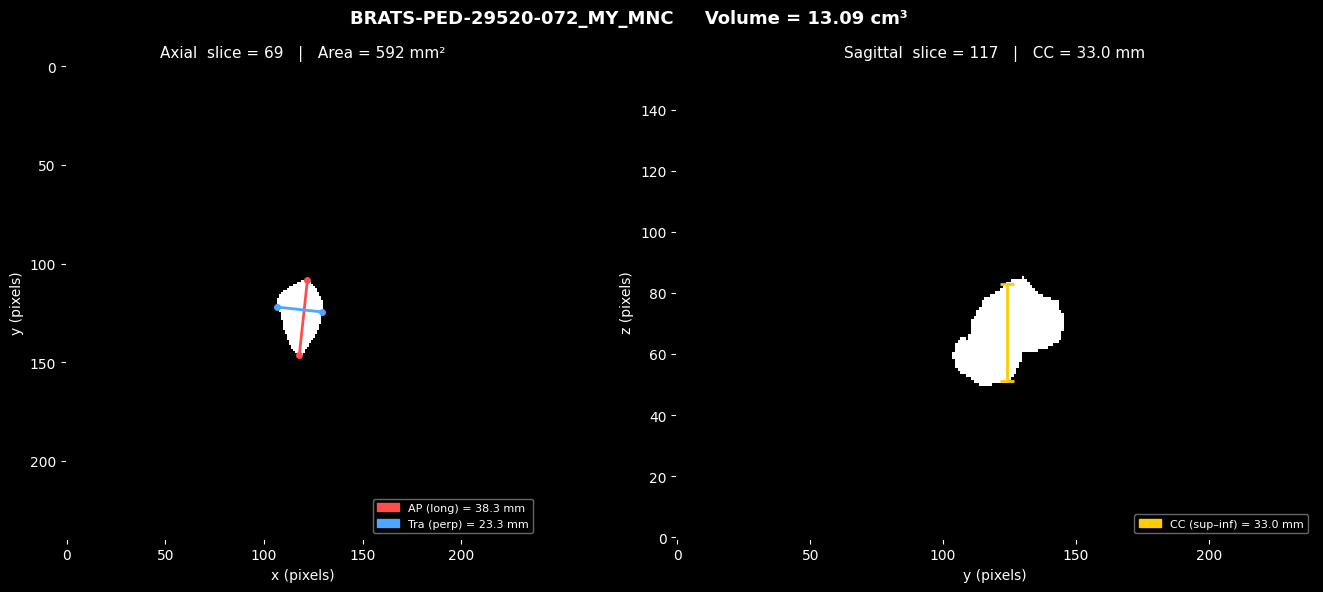

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def visualize_case(case: CaseMeasurement) -> None:
    """Side-by-side axial and sagittal views with measurement overlays."""
    if case.whole_tumor_mask is None:
        print("No mask stored — call measure_case with keep_mask=True.")
        return
    if case.axial_slice_index < 0:
        print(f"{case.case_id}: no tumor voxels to visualize.")
        return

    mask = case.whole_tumor_mask
    z = case.axial_slice_index
    x_sag = case.sagittal.slice_index if case.sagittal else 0

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor="black")
    for ax in axes:
        ax.set_facecolor("black")

    # ── Axial slice ──────────────────────────────────────────────────────────
    ax_ax = axes[0]
    ax_ax.imshow(mask[z], cmap="gray", interpolation="nearest")

    if case.axial and case.axial.long_endpoints is not None:
        p1, p2 = case.axial.long_endpoints
        ax_ax.plot(
            [p1[0], p2[0]], [p1[1], p2[1]],
            "-", color="#ff4d4d", linewidth=2,
        )
        ax_ax.plot(
            [p1[0], p2[0]], [p1[1], p2[1]],
            "o", color="#ff4d4d", markersize=4,
        )

    if case.axial and case.axial.short_endpoints is not None:
        q1, q2 = case.axial.short_endpoints
        ax_ax.plot(
            [q1[0], q2[0]], [q1[1], q2[1]],
            "-", color="#4da6ff", linewidth=2,
        )
        ax_ax.plot(
            [q1[0], q2[0]], [q1[1], q2[1]],
            "o", color="#4da6ff", markersize=4,
        )

    long_patch = mpatches.Patch(color="#ff4d4d", label=f"AP (long) = {case.ap_mm:.1f} mm")
    short_patch = mpatches.Patch(color="#4da6ff", label=f"Tra (perp) = {case.tra_mm:.1f} mm")
    ax_ax.legend(handles=[long_patch, short_patch], loc="lower right", fontsize=8,
                 facecolor="black", edgecolor="gray", labelcolor="white")
    ax_ax.set_title(f"Axial  slice = {z + 1}   |   Area = {case.area_mm2:.0f} mm²",
                    color="white", fontsize=11)
    ax_ax.set_xlabel("x (pixels)", color="white")
    ax_ax.set_ylabel("y (pixels)", color="white")
    ax_ax.tick_params(colors="white")

    # ── Sagittal slice ───────────────────────────────────────────────────────
    ax_sg = axes[1]
    # Display the sagittal slice with y on the horizontal axis (left=anterior)
    # and z on the vertical axis (origin lower so z increases upward).
    sag = mask[:, :, x_sag]  # shape (Z, Y); plot coords are (y_pix, z_pix)
    ax_sg.imshow(sag, cmap="gray", aspect="auto", origin="lower", interpolation="nearest")

    if case.sagittal is not None:
        # Anchor the CC ruler to the actual (y, z_lo)–(y, z_hi) column on this
        # sagittal slice that produced the max superior–inferior span. Both
        # endpoints are guaranteed to sit on real tumor voxels, so the line
        # cannot drift outside the mask the way an average-y placement did.
        y_col = case.sagittal.y_at_max
        z_lo, z_hi = case.sagittal.z_lo, case.sagittal.z_hi
        ax_sg.plot(
            [y_col, y_col], [z_lo, z_hi],
            "-", color="#ffcc00", linewidth=2,
        )
        ax_sg.plot(
            [y_col, y_col], [z_lo, z_hi],
            "_", color="#ffcc00", markersize=10, markeredgewidth=2,
        )
        cc_patch = mpatches.Patch(color="#ffcc00", label=f"CC (sup–inf) = {case.cc_mm:.1f} mm")
        ax_sg.legend(handles=[cc_patch], loc="lower right", fontsize=8,
                     facecolor="black", edgecolor="gray", labelcolor="white")

    ax_sg.set_title(f"Sagittal  slice = {x_sag + 1}   |   CC = {case.cc_mm:.1f} mm",
                    color="white", fontsize=11)
    ax_sg.set_xlabel("y (pixels)", color="white")
    ax_sg.set_ylabel("z (pixels)", color="white")
    ax_sg.tick_params(colors="white")

    fig.suptitle(
        f"{case.case_id}     Volume = {case.volume_cm3:.2f} cm³",
        color="white", fontsize=13, fontweight="bold",
    )
    fig.tight_layout()
    plt.show()


# ── Pick a case to visualize ─────────────────────────────────────────────────
VISUALIZE_CASE_ID = "BRATS-PED-29520-072_MY_MNC"  # <-- change this to any case_id from the CSV

_viz_dir = next(
    (d for d in iter_case_dirs(DATA_DIR) if case_id_from_dir(d) == VISUALIZE_CASE_ID),
    None,
)
if _viz_dir is not None:
    _viz_result = measure_case(_viz_dir, keep_mask=True)
    if _viz_result is not None:
        visualize_case(_viz_result)
    else:
        print(f"Could not measure {VISUALIZE_CASE_ID}")
else:
    print(f"Case directory not found for {VISUALIZE_CASE_ID}")